In [10]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 2.7
control_thresh = 2.9

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [11]:
pre_opto = ['AE_344','AE_346','AE_367']
pre_control = ['AE_350','AE_359','AE_418','AE_498','AE_351']

all_animals = np.concatenate([pre_opto, pre_control])

In [12]:
df = pd.read_csv(os.path.join('..','..','Source Data Files','Figure 3o.csv'))

In [13]:
df

,Unnamed: 0,animal,session,cluster ID,learning phase,FR modulation
0,0,AE_344,AE_344_10_opto_AC.pickle,15,3,6.958333
1,1,AE_344,AE_344_10_opto_AC.pickle,18,3,1.458333
2,2,AE_344,AE_344_10_opto_AC.pickle,27,3,11.833333
3,3,AE_344,AE_344_10_opto_AC.pickle,30,3,1.875000
4,4,AE_344,AE_344_10_opto_AC.pickle,46,3,10.393701
...,...,...,...,...,...,...
1560,1560,AE_498,AE_498_5_opto_control_AC.pickle,281,pre expert,1.754386
1561,1561,AE_498,AE_498_5_opto_control_AC.pickle,283,pre expert,1.987421
1562,1562,AE_498,AE_498_5_opto_control_AC.pickle,285,pre expert,2.113208
1563,1563,AE_498,AE_498_5_opto_control_AC.pickle,289,pre expert,1.836478


In [14]:
opto_early_FRmods = []
opto_late_FRmods = []
opto_expert_FRmods = []

for animal in pre_opto:
        
    animal_earlyFRmods = []
    animal_lateFRmods = []
    animal_expertFRmods = []
    if animal in pre_opto:
        df_animal = df[df['animal'] == animal]
        for row in df_animal.iloc():

            if row['learning phase'] == '1':
                animal_earlyFRmods.append(row['FR modulation'])
            elif row['learning phase'] == '2':
                animal_lateFRmods.append(row['FR modulation'])
            elif row['learning phase'] == '3':
                animal_expertFRmods.append(row['FR modulation'])
        animal_earlyFRmods = np.array(ilep.rmnan(animal_earlyFRmods),dtype='object')
        animal_lateFRmods = np.array(ilep.rmnan(animal_lateFRmods),dtype='object')
        animal_expertFRmods = np.array(ilep.rmnan(animal_expertFRmods),dtype='object')
        opto_early_FRmods.append(animal_earlyFRmods)
        opto_late_FRmods.append(animal_lateFRmods)
        opto_expert_FRmods.append(animal_expertFRmods)
    else:
        pass

control_early_FRmods = []
control_late_FRmods = []
control_expert_FRmods = []
for animal in pre_control:
    
    animal_earlyFRmods = []
    animal_lateFRmods = []
    animal_expertFRmods = []
    if animal in pre_control:
        df_animal = df[df['animal'] == animal]
        for row in df_animal.iloc():
            
            if row['learning phase'] == 'pre early':
                animal_earlyFRmods.append(row['FR modulation'])
            elif row['learning phase'] == 'pre late':
                animal_lateFRmods.append(row['FR modulation'])
            elif row['learning phase'] == 'pre expert':
                animal_expertFRmods.append(row['FR modulation'])
        animal_earlyFRmods = np.array(ilep.rmnan(animal_earlyFRmods),dtype='object')
        animal_lateFRmods = np.array(ilep.rmnan(animal_lateFRmods),dtype='object')
        animal_expertFRmods = np.array(ilep.rmnan(animal_expertFRmods),dtype='object')
        control_early_FRmods.append(animal_earlyFRmods)
        control_late_FRmods.append(animal_lateFRmods)
        control_expert_FRmods.append(animal_expertFRmods)
    else:
        pass




In [15]:
mean_pc_NCR = []
sem_pc_NCR = []
for FRmods in [opto_early_FRmods, opto_late_FRmods, opto_expert_FRmods]:
    # print(FRmods)
    Mw,SEMw = ilep.bootstrap_Mw_SEMw(FRmods,n_frac=1,CR_NCR_thresh=opto_thresh)
    mean_pc_NCR.append(Mw)
    sem_pc_NCR.append(SEMw)

mean_pc_NCR = [100 - x for x in mean_pc_NCR]

In [16]:
mean_pc_NCR_control = []
sem_pc_NCR_control = []
for FRmods in [control_early_FRmods, control_late_FRmods, control_expert_FRmods]:
    Mw,SEMw = ilep.bootstrap_Mw_SEMw(FRmods,n_frac=1,CR_NCR_thresh=control_thresh)
    mean_pc_NCR_control.append(Mw)
    sem_pc_NCR_control.append(SEMw)

mean_pc_NCR_control = [100 - x for x in mean_pc_NCR_control]

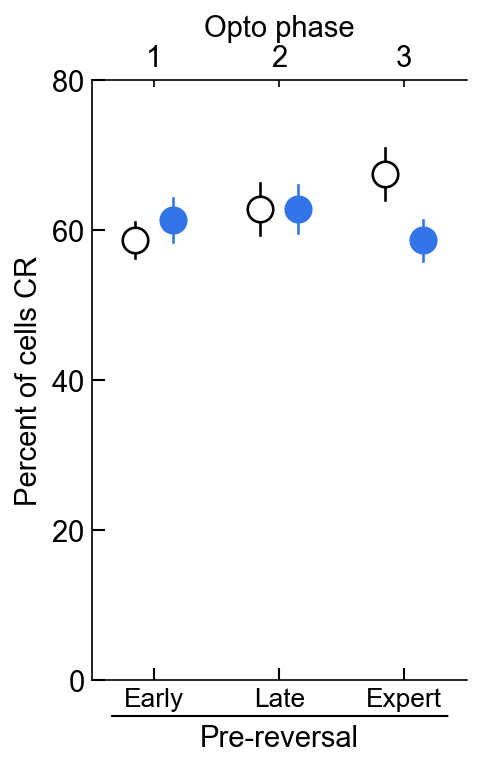

In [17]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

def statsbar(ax,barheight,xpoints,stemheights,text=None,lw=1):
    ymax = ax.get_ylim()[1]
    ymin = ax.get_ylim()[0]
    yrange = ymax-ymin
    ydist = 0.025*yrange
    
    ax.plot([xpoints[0]]*2,[stemheights[0]+ydist,barheight],lw=lw,color='k')
    ax.plot([xpoints[1]]*2,[stemheights[1]+ydist,barheight],lw=lw,color='k')
    ax.plot(xpoints,[barheight]*2,lw=lw,color='k')
    
    if not text is None:
        ax.text(np.mean(xpoints),barheight + ydist,text,horizontalalignment='center',verticalalignment='center')

fig,ax = make_axis_size(2.5, 4, left=.3, bottom=.3, right=0, top=0)
switch_offset = 0#

################################################################################################################

wid = 0
offset=0.15
for idx,p in zip(range(6),[1,1,1]):

    ax.scatter([idx+wid+p*switch_offset-offset],(mean_pc_NCR_control[idx]),ec='k',fc='white',s=150,zorder=10,marker='o',lw=1.25)
    ax.plot([idx+wid+p*switch_offset-offset,idx+wid+p*switch_offset-offset],[(mean_pc_NCR_control[idx]-sem_pc_NCR_control[idx]),(mean_pc_NCR_control[idx]+sem_pc_NCR_control[idx])],color='k',lw=1.25,zorder=9)
    
    ax.scatter([idx+wid+p*switch_offset+offset],(mean_pc_NCR[idx]),c=LASER_COLOR,s=150,zorder=10,marker='o',lw=1.25)
    ax.plot([idx+wid+p*switch_offset+offset,idx+wid+p*switch_offset+offset],[(mean_pc_NCR[idx]-sem_pc_NCR[idx]),(mean_pc_NCR[idx]+sem_pc_NCR[idx])],color=LASER_COLOR,lw=1.25,zorder=9)

################################################################################################################

labels = ['Early','Late','Expert']

ylab = ax.set_ylabel('Percent of cells CR')
ax.set_ylim([0,80])
ax.set_yticks([0,20,40,60,80])
              
ax.set_xlim([-0.5-switch_offset,2.5+switch_offset])
ax.set_xticks([0-switch_offset,1-switch_offset,2-switch_offset])
ax.set_xticklabels(labels)

sec_x = ax.secondary_xaxis('top')
sec_x.set_xticks([0-switch_offset,1-switch_offset,2-switch_offset])
sec_x.set_xticklabels(['1','2','3'])
sxlab = sec_x.set_xlabel('Opto phase')


stdyfrac = 0.06
xtick_pos_pre = ax.get_xticks()[1]
Yval = ilep.getPrePostLabelYval(ax.get_ylim(),Yfrac=-2*stdyfrac)
t1 = ax.text(xtick_pos_pre, Yval, 'Pre-reversal', ha='center', va='bottom', fontsize=stdfont,color='k')
ax.annotate('', xy=(0.0425, -stdyfrac), xycoords='axes fraction', xytext=(0.96, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))

ax.tick_params(direction='in', length=3, width=1)

ax.tick_params(direction='in', length=6, width=1)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label,sec_x.xaxis.label,t1] +
    ax.get_xticklabels() + ax.get_yticklabels() + sec_x.get_xticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass

artists = [ylab,sec_x,t1]

# fig.savefig(os.path.join('..','..','Figures','Figure 3o.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [18]:
Xs = [opto_early_FRmods, opto_late_FRmods, opto_expert_FRmods]
Ys = [control_early_FRmods, control_late_FRmods,control_expert_FRmods]

pvals = [np.nan]*3
for idx,(X,Y) in enumerate(zip(Xs,Ys)):
    X = np.array(X,dtype='object')
    Y = np.array(Y,dtype='object')
    pvals[idx] = ilep.bootstrap_pc_NCR_test(X,Y,B=25000,CR_NCR_thresh=[opto_thresh,control_thresh])
    print(f'{labels[idx]}: {pvals[idx]}')

Early: 0.47584000000000004
Late: 0.9685600000000001
Expert: 0.04615999999999998
